# CodeAlpha Data Science Internship

## Task 4: Sales Prediction using Python

**Submitted By:** Soni Kajal Kamleshbhai

### Objective

To build a machine learning model that predicts product sales based on advertising expenditure across different media platforms such as TV, Radio, and Newspaper.

In [1]:
# ============================================
# Import Required Libraries
# ============================================

import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("Datasets/Advertising.csv")

In [3]:
display(df.head())

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print("Dataset Shape :", df.shape)

Dataset Shape : (200, 5)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
# Remove unnecessary column

if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# Check Missing Values

print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [9]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## Exploratory Data Analysis

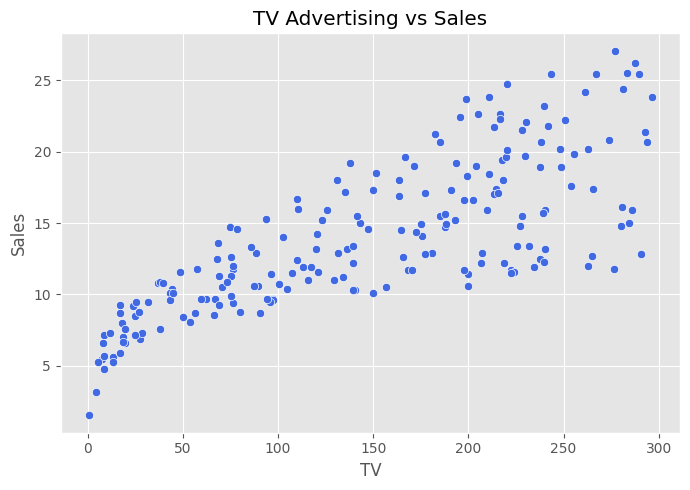

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="TV", y="Sales", color="royalblue")

plt.title("TV Advertising vs Sales")

plt.tight_layout()

plt.savefig("Screenshots/tv_vs_sales.png", dpi=300)

plt.show()

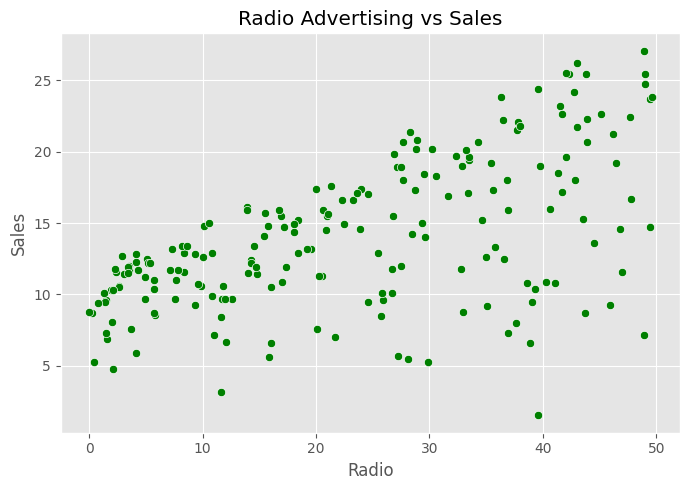

In [11]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="Radio", y="Sales", color="green")

plt.title("Radio Advertising vs Sales")

plt.tight_layout()

plt.savefig("Screenshots/radio_vs_sales.png", dpi=300)

plt.show()

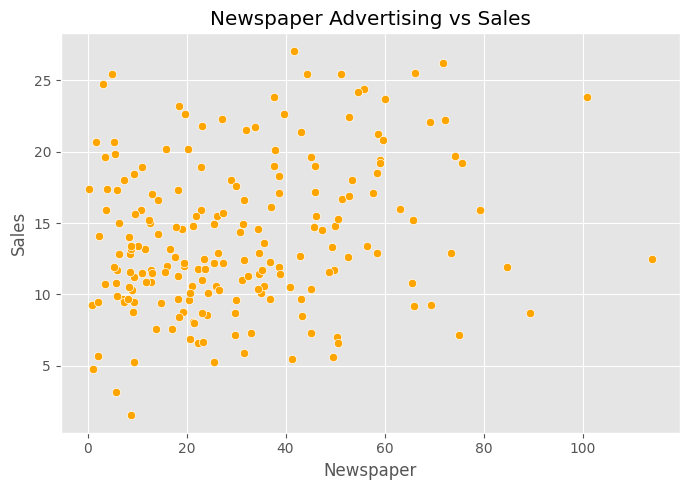

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="Newspaper", y="Sales", color="orange")

plt.title("Newspaper Advertising vs Sales")

plt.tight_layout()

plt.savefig("Screenshots/newspaper_vs_sales.png", dpi=300)

plt.show()

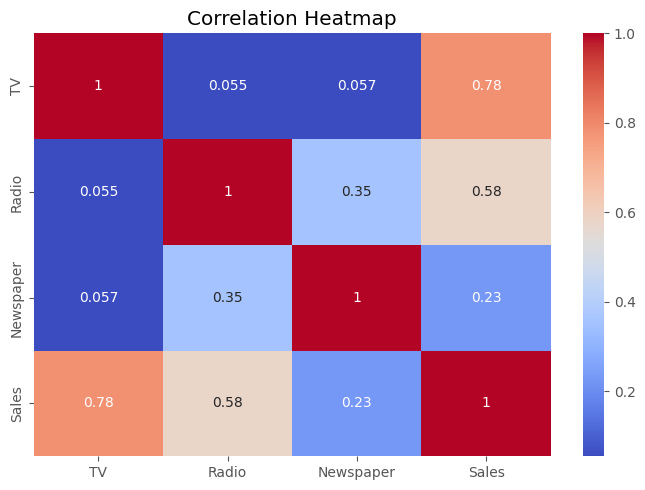

In [13]:
plt.figure(figsize=(7,5))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("Screenshots/correlation_heatmap.png", dpi=300)

plt.show()

## Model Building

In [14]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
predictions = model.predict(X_test)

## Model Evaluation

In [18]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", round(mae,2))

print("Root Mean Squared Error :", round(rmse,2))

print("R2 Score :", round(r2,2))

Mean Absolute Error : 1.46
Root Mean Squared Error : 1.78
R2 Score : 0.9


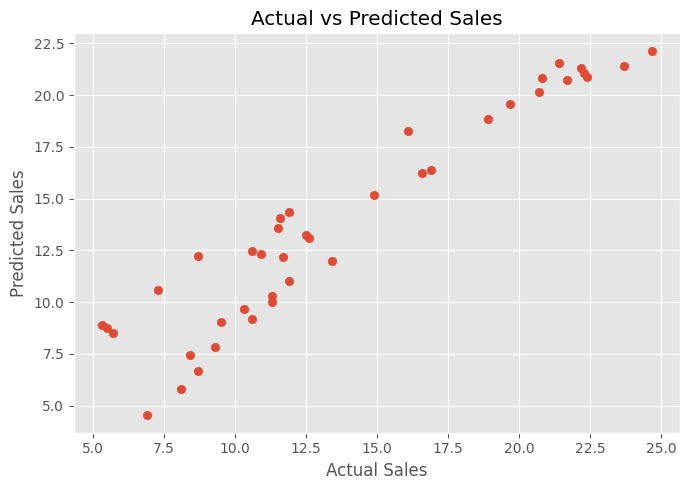

In [19]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.tight_layout()

plt.savefig("Screenshots/actual_vs_predicted_sales.png", dpi=300)

plt.show()

In [20]:
prediction_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

display(prediction_df.head(10))

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


## Conclusion

In this project, a Linear Regression model was developed to predict product sales based on advertising expenditure on TV, Radio, and Newspaper.

Exploratory data analysis revealed the relationship between advertising channels and sales. The model was evaluated using MAE, RMSE, and R² Score to measure its performance.

This project demonstrates how machine learning can help businesses estimate future sales and make informed marketing decisions based on advertising investments.